#**PYTHON 🐍 EDA of E-commerce Project**


##**🚀 Import & Setup Data**


In [29]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# ==============================
# 2. LOAD DATA
# ==============================

customers = pd.read_csv("/content/customers.csv", parse_dates=["signup_date"])
products = pd.read_csv("/content/products.csv")
orders = pd.read_csv("/content/orders.csv", parse_dates=["order_date", "delivery_date"])
returns = pd.read_csv("/content/returns.csv", parse_dates=["return_date"])

print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Returns:", returns.shape)

Customers: (8000, 5)
Products: (992, 5)
Orders: (50000, 10)
Returns: (11000, 6)


##**Data Validation & Cleaning**

###**1️⃣ Check Duplicates**

In [30]:
print("Duplicate Orders:", orders.duplicated().sum())
print("Duplicate Customers:", customers.duplicated().sum())
print("Duplicate Products:", products.duplicated().sum())
print("Duplicate Returns:", returns.duplicated().sum())


Duplicate Orders: 0
Duplicate Customers: 0
Duplicate Products: 0
Duplicate Returns: 0


###**2️⃣ Null Value Check**


In [31]:
print(orders.isnull().sum())
print(returns.isnull().sum())

order_id           0
order_date         0
customer_id        0
product_id         0
quantity           0
selling_price      0
discount_amount    0
payment_type       0
shipping_cost      0
delivery_date      0
dtype: int64
return_id                0
order_id                 0
return_date              0
return_reason            0
refund_amount            0
refund_processed_days    0
dtype: int64


###**3️⃣ Logical Validation**

In [32]:
orders["order_net_value"] = orders["selling_price"] - orders["discount_amount"]

merged_check = returns.merge(
    orders[["order_id", "order_net_value"]],
    on="order_id",
    how="left"
)

anomaly = merged_check[merged_check["refund_amount"] > merged_check["order_net_value"]]
print("Refund Anomalies:", anomaly.shape[0])

Refund Anomalies: 1172


#**MERGE ALL TABLES**

In [33]:
#Merge Orders + Customers
df= orders.merge(customers, on="customer_id", how = "left")

# Merge Products
df= df.merge(products,on="product_id", how= "left")

# Merge Returns
df= df.merge(returns, on="order_id", how="left")

print(df.shape)

(50000, 24)


#**FEATURE ENGINEERING**

###**Revenue Metrics**

In [34]:
df["net_revenue"] = df["selling_price"] - df["discount_amount"]
df["gross_revenue"] = df["selling_price"] * df["quantity"]
df["discount_pct"] = df["discount_amount"] / df["selling_price"]
df["order_value"] = df["net_revenue"] * df["quantity"]


###**Cost & Profit Metrics**

In [35]:
df["total_cost"]= df["cost_price"]*df["quantity"]
df["gross_profit"] = df["order_value"] - df["total_cost"] - df["shipping_cost"]
df["profit_margin_pct"] = df["gross_profit"] / df["order_value"]

###**Return Intelligence**

In [36]:
df["return_flag"] = np.where(df["return_id"].notna(), 1, 0)

df["return_loss"] = np.where(
    df["return_flag"] == 1,
    df["refund_amount"] + df["shipping_cost"],
    0
)

df["refund_delay_flag"] = np.where(
    df["refund_processed_days"] > 5, 1, 0
)

###**Customer Intelligence**

In [37]:
customer_summary = df.groupby("customer_id").agg(
    total_orders=("order_id", "count"),
    total_return=("return_flag", "sum"),
    total_revenue=("order_value", "sum"),
    total_profit=("gross_profit", "sum")
).reset_index()

customer_summary["customer_return_rate"] = (
    customer_summary["total_return"] /
    customer_summary["total_orders"]
)

df = df.merge(customer_summary, on="customer_id", how="left")

###**Product Intelligence**

In [38]:
product_summary = df.groupby("product_id").agg(
    product_orders=("order_id", "count"),
    product_returns=("return_flag", "sum"),
    product_profit=("gross_profit", "sum")
).reset_index()

product_summary["product_return_rate"] = (
    product_summary["product_returns"] /
    product_summary["product_orders"]
)

df = df.merge(product_summary, on="product_id", how="left")

#**EDA**

###**1️⃣ Overall KPIs**

In [39]:
total_revenue = df["order_value"].sum()
total_profit = df["gross_profit"].sum()
total_return_loss = df["return_loss"].sum()
return_rate = df["return_flag"].mean()

print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Return Loss:", total_return_loss)
print("Return Rate:", return_rate)

Total Revenue: 360185867.48
Total Profit: 90863557.47999997
Return Loss: 40742914.04
Return Rate: 0.22


##**2️⃣ Profit by Category**

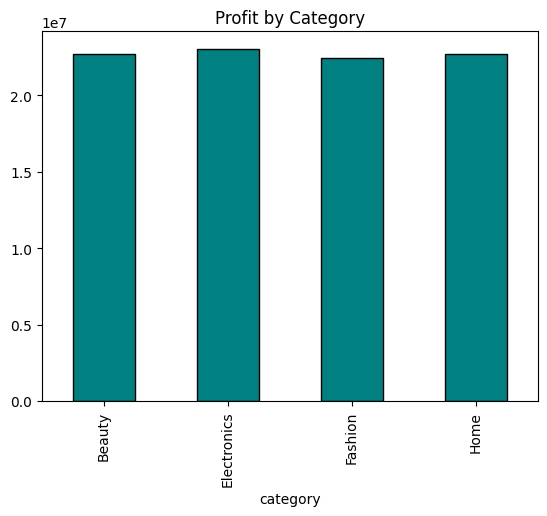

In [40]:
category_profit = df.groupby("category")["gross_profit"].sum()
category_profit.plot(kind="bar", title="Profit by Category",color="teal", edgecolor="black")
plt.show()

##**3️⃣ Return Rate by Payment Type**

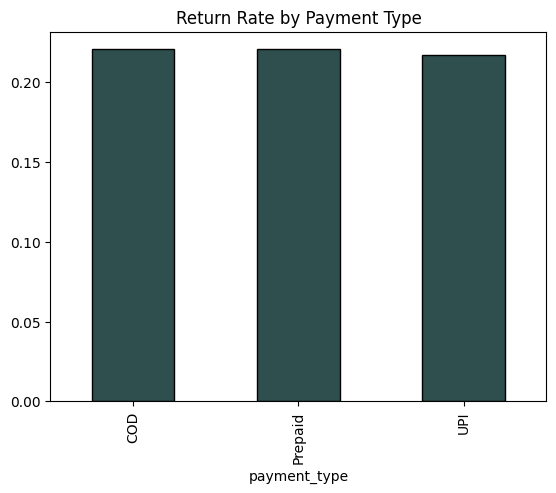

In [41]:
payment_returns = df.groupby("payment_type")["return_flag"].mean()
payment_returns.plot(kind="bar", title="Return Rate by Payment Type",color="darkslategray", edgecolor="black")
plt.show()


##**4️⃣ Top 10 Loss-Making Products**

In [42]:
loss_products = (
    df.groupby("product_id")["gross_profit"]
    .sum()
    .sort_values()
    .head(10)
)

print(loss_products)

product_id
600     857.43
908    1391.11
29     2040.51
631    2218.55
702    2229.87
15     2298.27
272    2396.51
750    2686.72
157    2693.09
174    3147.91
Name: gross_profit, dtype: float64


##**5️⃣ Serial Returners**

In [43]:
serial_returners = customer_summary[
    customer_summary["customer_return_rate"] > 0.5
]

print(serial_returners.head())

     customer_id  total_orders  total_return  total_revenue  total_profit  \
4              5             7             4       49358.05      11262.05   
67            68             3             2       19889.12       5617.12   
152          153             3             2       19027.25       4641.25   
173          174             4             3       35509.10       6003.10   
220          221             7             4       68710.04      19993.04   

     customer_return_rate  
4                0.571429  
67               0.666667  
152              0.666667  
173              0.750000  
220              0.571429  


#**🗄EXPORT CLEAN DATA FOR SQL**

In [44]:
df.to_csv("final_analytics_dataset.csv", index=False)